In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

### 1️⃣ Load Dataset

In [2]:
vocab_size = 10000  # keep top 10k words

In [3]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


### 2️⃣ Preprocessing (Padding)

In [5]:
max_length = 200

In [6]:
x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')

In [7]:
print("Shape after padding:", x_train.shape)

Shape after padding: (25000, 200)


### 3️⃣ Build Model

In [8]:
model = keras.Sequential([
    keras.layers.Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Binary output
])

D:\ANACONDA\envs\lpdeeplearn\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4️⃣ Train Model

In [11]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5957 - loss: 0.6417 - val_accuracy: 0.8446 - val_loss: 0.3483
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9201 - loss: 0.2110 - val_accuracy: 0.8582 - val_loss: 0.3453
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9880 - loss: 0.0464 - val_accuracy: 0.8612 - val_loss: 0.4328
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9975 - loss: 0.0105 - val_accuracy: 0.8600 - val_loss: 0.5093
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.8504 - val_loss: 0.5636


### 5️⃣ Evaluate Model

In [12]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8363 - loss: 0.5988
Test Accuracy: 0.8340399861335754


### 6️⃣ Visualization

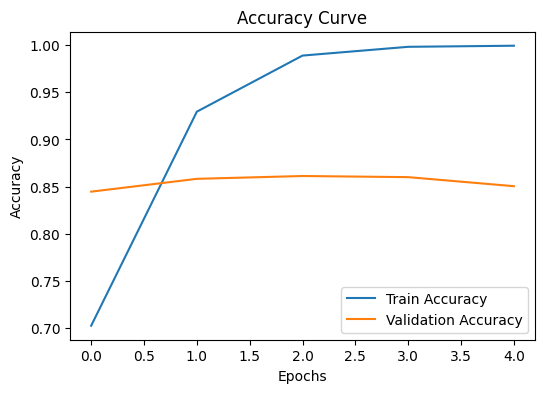

In [13]:
# 📊 Accuracy Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

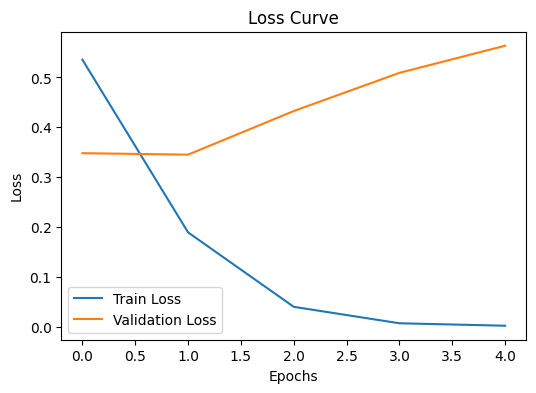

In [14]:
# 📊 Loss Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [16]:
y_pred = (model.predict(x_test) > 0.5).astype("int32")


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [20]:
# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.84     12500
           1       0.85      0.81      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [21]:

cm = confusion_matrix(y_test, y_pred)



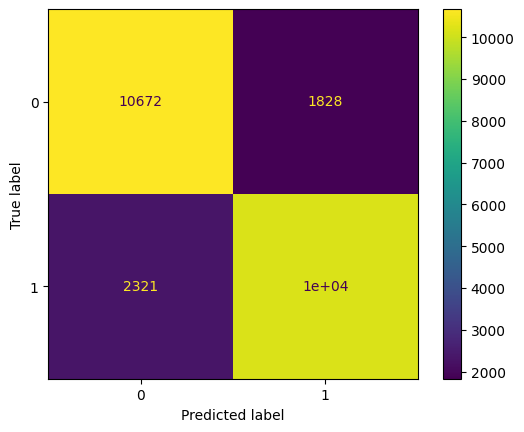

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()